# Semantic ridge encoding visualization (Lexical Delay)

Explore GloVe → HGA encoding maps from `results/semantic/LexicalDelay/`.

**Main result:** inflated-surface **Gaussian KDE** maps of cluster-significant electrodes in phase-specific time windows, **Decision vs Repeat** side by side (method from `vizpub/fig3_rt_legacy.ipynb`; coordinates from current hammers `x_t,y_t,z_t` — **no offset**).

| Phase | Time window (epoch-relative) |
|-------|------------------------------|
| Stimulus | 0 – 0.5 s |
| Delay | 0 – 0.5 s |
| Go | 0 – 0.5 s |
| Response | −0.5 – 0.5 s |

Density is computed on **pial** vertices (anatomical distance), displayed on **inflated** cortex so insula is visible. Weight = peak `|r|` inside the window. KDE is a spatial overview, not a new significance test.

**Significance:** fold-inner token→GloVe shuffle (`n_perm=500`) + per-channel time-cluster correction (`p<0.05`).

Style follows [`vizpub/fig4.ipynb`](../vizpub/fig4.ipynb) / [`vizpub/fig2.ipynb`](../vizpub/fig2.ipynb). Display only.

> Restart kernel and Run All after the full encoding sweep finishes.


In [23]:
import importlib
import os
import sys
from pathlib import Path

# Headless HPC: avoid EGL /dev/dri errors (must be set before pyvista import)
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
os.environ.setdefault("VTK_DEFAULT_RENDER_WINDOW_OFFSCREEN", "1")
os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

import rootutils


def _find_project_root(start: Path | None = None) -> Path:
    """Walk upward from likely start dirs until `.project-root` is found."""
    starts: list[Path] = []
    if start is not None:
        starts.append(Path(start))
    starts.append(Path.cwd())
    starts.append(Path.cwd() / "insula-semantic")
    starts.append(Path("/hpc/group/coganlab/nanlinshi/insula-semantic"))

    seen: set[Path] = set()
    for raw in starts:
        base = raw.resolve()
        if base in seen:
            continue
        seen.add(base)
        for candidate in (base, *base.parents):
            if (candidate / ".project-root").exists():
                return candidate

    raise FileNotFoundError(
        "Project root not found. cd to insula-semantic or set cwd in Jupyter to the repo."
    )


PROJECT_ROOT = _find_project_root()
rootutils.setup_root(
    PROJECT_ROOT,
    indicator=".project-root",
    pythonpath=True,
    cwd=True,
)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import pandas as pd
import seaborn as sns
import h5py
import mne
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist
from IPython.display import display

import src.semantic.load_encoding_results as load_encoding_results
importlib.reload(load_encoding_results)
from src.semantic.load_encoding_results import (
    load_encoding_long,
    build_roi_timeseries,
    DEFAULT_RESULTS_DIR,
)


In [24]:
# vizpub style (fig2 / fig4)
cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"

fontdict = dict(fontsize=7)
fontsize = 7

red = "#A9373B"
blue = "#2369BD"
orange = "#CC8963"
green = "#009944"

stg_color = "#20B2AA"
smc_color = "#6A5ACD"
insula_color = "#D4AF37"

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

# Major ROI groups (Hammers → fig2 convention; see load_encoding_results.roi_group_label)
MAJOR_ROIS = ["AIC", "PIC", "STG", "SMC", "IFG", "MFG"]
ROI_COLORS = {
    "AIC": red,
    "PIC": blue,
    "STG": stg_color,
    "SMC": smc_color,
    "IFG": orange,
    "MFG": green,
}
ROI_CMAPS = {
    "AIC": reds,
    "PIC": blues,
    "STG": sns.light_palette(stg_color, as_cmap=True),
    "SMC": sns.light_palette(smc_color, as_cmap=True),
    "IFG": oranges,
    "MFG": greens,
}

recon_dir = "/cwork/ns458/ECoG_Recon/"


def setup_brain_offscreen() -> None:
    """Virtual framebuffer for MNE Brain on login nodes without GPU."""
    if getattr(setup_brain_offscreen, "_done", False):
        return
    import warnings

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        try:
            pv.start_xvfb()
        except Exception:
            pass
    mne.viz.set_3d_backend("notebook")
    setup_brain_offscreen._done = True


setup_brain_offscreen()

/hpc/home/ns458/miniconda3/envs/ieeg/lib/python3.11/site-packages/pyvista/plotting/utilities/xvfb.py:48: PyVistaDeprecationWarning: This function is deprecated and will be removed in future version of PyVista. Use vtk-osmesa instead.
  warnings.warn(


## Load encoding results

Loads all `phase × description` H5 files. Inventory shows coverage. Time-window filters for brain maps are defined here as `TIME_WINDOWS`.


In [25]:
RESULTS_DIR = DEFAULT_RESULTS_DIR
EXPECTED_SUBJECTS = 52
PHASES = ["Stimulus", "Delay", "Go", "Response"]
DESCRIPTIONS = ["Decision", "Repeat"]

# Phase-specific windows for selecting significant electrodes (closed interval).
TIME_WINDOWS = {
    "Stimulus": (0.0, 0.5),
    "Delay": (0.0, 0.5),
    "Go": (0.0, 0.5),
    "Response": (-0.5, 0.5),
}

# Used by ROI curves / heatmaps / optional explorer (secondary views).
DESCRIPTION = "Decision"

channels_all, long_all = load_encoding_long(results_dir=RESULTS_DIR)

required_cols = {"x_t", "y_t", "z_t", "phase", "description"}
missing_cols = required_cols - set(channels_all.columns)
if missing_cols:
    raise RuntimeError(
        f"Missing columns {missing_cols}. Restart kernel and re-run imports "
        "(load_encoding_results.py must expose phase/description + CVS coords)."
    )

inventory = (
    channels_all.groupby(["description", "phase"])["subject"]
    .nunique()
    .unstack("phase")
    .reindex(index=DESCRIPTIONS, columns=PHASES)
    .fillna(0)
    .astype(int)
)
print("Subjects with H5 per condition (expect 52 each):")
display(inventory)
n_h5 = int(channels_all.groupby(["subject", "phase", "description"]).ngroups)
print(
    f"Loaded condition files: {n_h5} / "
    f"{EXPECTED_SUBJECTS * len(PHASES) * len(DESCRIPTIONS)}"
)

has_cluster_sig = bool(channels_all.get("has_significance", pd.Series([False])).any())
sig_label = "none (re-run with --n_perm)"
if has_cluster_sig:
    channels_all["significant"] = channels_all["ch_sig_any"].fillna(False).astype(bool)
    long_all["significant"] = long_all["significant"].fillna(False).astype(bool)
    sig_label = "cluster p<0.05 (per channel, time cluster)"

    peak_keys = ["subject", "channel", "phase", "description"]
    peak_sig = (
        long_all.loc[long_all["significant"] == True, peak_keys + ["abs_r"]]
        .groupby(peak_keys, as_index=False)["abs_r"]
        .max()
        .rename(columns={"abs_r": "peak_sig_abs_r"})
    )
    channels_all = channels_all.merge(peak_sig, on=peak_keys, how="left")
    channels_all["effect"] = channels_all["peak_sig_abs_r"].fillna(0.0)
else:
    print(
        "WARNING: H5 files lack mask/p_values. Re-run encoding with --n_perm."
    )
    channels_all["significant"] = False
    channels_all["effect"] = channels_all["ch_mean_abs_r"]


def spatial_sig_in_window(
    phase: str,
    description: str,
    tmin: float | None = None,
    tmax: float | None = None,
) -> pd.DataFrame:
    """Channels with any cluster-sig sample inside [tmin, tmax] for one condition.

    ``effect`` = peak |r| within the window (not the full epoch).
    """
    if tmin is None or tmax is None:
        tmin, tmax = TIME_WINDOWS[phase]

    meta_cols = [
        "subject",
        "channel",
        "roi",
        "roi_group",
        "hemi",
        "mix",
        "x_t",
        "y_t",
        "z_t",
    ]
    meta = channels_all[
        (channels_all["phase"] == phase)
        & (channels_all["description"] == description)
        & (~channels_all["mix"].fillna(True))
        & channels_all["x_t"].notna()
    ][meta_cols].drop_duplicates(subset=["subject", "channel"])

    if not has_cluster_sig or meta.empty:
        return meta.iloc[0:0].copy()

    win = long_all[
        (long_all["phase"] == phase)
        & (long_all["description"] == description)
        & (long_all["significant"] == True)
        & (long_all["time"] >= tmin)
        & (long_all["time"] <= tmax)
    ]
    if win.empty:
        out = meta.iloc[0:0].copy()
        out["effect"] = pd.Series(dtype=float)
        out["significant"] = pd.Series(dtype=bool)
        out["phase"] = pd.Series(dtype=str)
        out["description"] = pd.Series(dtype=str)
        return out

    peak = (
        win.groupby(["subject", "channel"], as_index=False)["abs_r"]
        .max()
        .rename(columns={"abs_r": "effect"})
    )
    out = meta.merge(peak, on=["subject", "channel"], how="inner")
    out["significant"] = True
    out["phase"] = phase
    out["description"] = description
    return out


# Windowed sig counts (main selection rule)
count_rows = []
for desc in DESCRIPTIONS:
    for phase in PHASES:
        tmin, tmax = TIME_WINDOWS[phase]
        sp = spatial_sig_in_window(phase, desc, tmin, tmax)
        count_rows.append(
            {
                "description": desc,
                "phase": phase,
                "tmin": tmin,
                "tmax": tmax,
                "n_sig_ch": len(sp),
                "n_subjects": sp["subject"].nunique() if len(sp) else 0,
            }
        )
window_counts = pd.DataFrame(count_rows)
print(f"\nSignificance: {sig_label}")
print("Cluster-sig channels inside phase time windows:")
display(
    window_counts.pivot(index="description", columns="phase", values="n_sig_ch").reindex(
        index=DESCRIPTIONS, columns=PHASES
    )
)

# Secondary slices (ROI curves / heatmaps use DESCRIPTION)
long = long_all[long_all["description"] == DESCRIPTION].copy()
if has_cluster_sig and long["significant"].notna().any():
    roi_ts = build_roi_timeseries(long[long["significant"] == True])
else:
    roi_ts = build_roi_timeseries(long)

channels = channels_all[channels_all["description"] == DESCRIPTION].copy()
print(f"Secondary view DESCRIPTION={DESCRIPTION!r} (ROI/heatmap defaults)")


Subjects with H5 per condition (expect 52 each):


phase,Stimulus,Delay,Go,Response
description,,,,
Decision,52,52,52,52
Repeat,52,52,52,52


Loaded condition files: 416 / 416

Significance: cluster p<0.05 (per channel, time cluster)
Cluster-sig channels inside phase time windows:


phase,Stimulus,Delay,Go,Response
description,,,,
Decision,81,103,97,180
Repeat,105,68,62,216


Secondary view DESCRIPTION='Decision' (ROI/heatmap defaults)


## Significance summary

Counts of electrodes with cluster significance **inside each phase time window** (Decision vs Repeat).


,description,phase,tmin,tmax,n_sig_ch,n_subjects
0,Decision,Stimulus,0.0,0.5,81,39
1,Decision,Delay,0.0,0.5,103,42
2,Decision,Go,0.0,0.5,97,39
3,Decision,Response,-0.5,0.5,180,49
4,Repeat,Stimulus,0.0,0.5,105,38
5,Repeat,Delay,0.0,0.5,68,29
6,Repeat,Go,0.0,0.5,62,30
7,Repeat,Response,-0.5,0.5,216,47


Top ROIs (summed over phases, within time windows):


,description,roi,n
46,Repeat,STGp,72
19,Decision,STGp,68
22,Decision,Unknown,63
51,Repeat,pTL,62
24,Decision,pTL,55
35,Repeat,MFG,47
49,Repeat,Unknown,47
8,Decision,MFG,39
7,Decision,IFG,31
14,Decision,PrG,27


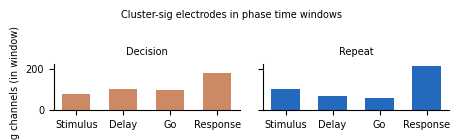

In [26]:
if not has_cluster_sig:
    print("Skip summary — no cluster significance in H5")
else:
    display(window_counts)

    # ROI breakdown within windows (pooled across subjects)
    roi_rows = []
    for desc in DESCRIPTIONS:
        for phase in PHASES:
            sp = spatial_sig_in_window(phase, desc)
            if sp.empty:
                continue
            vc = sp["roi"].value_counts()
            for roi, n in vc.items():
                roi_rows.append(
                    {"description": desc, "phase": phase, "roi": roi, "n": int(n)}
                )
    roi_win = pd.DataFrame(roi_rows)
    if not roi_win.empty:
        top = (
            roi_win.groupby(["description", "roi"], as_index=False)["n"]
            .sum()
            .sort_values("n", ascending=False)
        )
        print("Top ROIs (summed over phases, within time windows):")
        display(top.head(20))

    fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 3.5 * cm), sharey=True)
    for ax, desc in zip(axes, DESCRIPTIONS):
        sub = window_counts[window_counts["description"] == desc].set_index("phase").reindex(PHASES)
        ax.bar(range(len(PHASES)), sub["n_sig_ch"], color=orange if desc == "Decision" else blue, width=0.6)
        ax.set_xticks(range(len(PHASES)))
        ax.set_xticklabels(PHASES, fontsize=fontsize)
        ax.set_title(desc, fontsize=fontsize)
        ax.tick_params(labelsize=fontsize)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Sig channels (in window)", fontsize=fontsize)
    plt.suptitle("Cluster-sig electrodes in phase time windows", fontsize=fontsize)
    plt.tight_layout()
    plt.show()


## Main result: inflated Gaussian KDE (Decision vs Repeat)

Four figures (one per phase). Rows = **Decision / Repeat**; columns = left / right hemisphere.

- Select electrodes with cluster significance inside `TIME_WINDOWS[phase]`
- Coords: CVS template `x_t, y_t, z_t` (no offset)
- KDE on **pial** (`bandwidth=8` mm, `max_distance=12` mm), display on **inflated**
- Shared density color scale within each phase


In [27]:
# Helpers adapted from vizpub/fig4.ipynb

def _brain_screenshot(brain, mode="rgb"):
    """Render offscreen before screenshot (required on headless nodes)."""
    setup_brain_offscreen()
    brain._renderer.plotter.render()
    return brain.screenshot(mode=mode)


def hga_to_size(vals, vmin, vmax, size_min=5, size_max=25):
    normalized = np.clip((vals - vmin) / (vmax - vmin + 1e-12), 0, 1)
    return size_min + normalized * (size_max - size_min)


def add_electrodes_with_effect_colored(
    brain, coords, effect_vals, roi_vals, tree, pial_coords, vmin, vmax, size_min, size_max
):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i in range(len(coords_proj)):
        pt = coords_proj[i : i + 1]
        effect = effect_vals[i]
        roi = roi_vals[i]

        if roi == "AIC":
            color = reds(norm(effect))
        elif roi == "PIC":
            color = blues(norm(effect))
        else:
            color = "gray"

        size = hga_to_size(effect, vmin, vmax, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
        )


def add_electrodes_continuous(
    brain,
    coords,
    effect_vals,
    tree,
    pial_coords,
    cmap,
    vmin,
    vmax,
    size_min=4,
    size_max=18,
):
    """Whole-brain overlay: color/size by peak |r| (single colormap)."""
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    for i in range(len(coords_proj)):
        pt = coords_proj[i : i + 1]
        effect = effect_vals[i]
        color = cmap(norm(effect))
        size = hga_to_size(effect, vmin, vmax, size_min, size_max)
        cloud = pv.PolyData(pt)
        brain._renderer.plotter.add_mesh(
            cloud,
            render_points_as_spheres=True,
            point_size=size,
            color=color,
            lighting=False,
            smooth_shading=False,
        )


def compute_density_unified(surface_coords, electrode_coords, effect_values, bandwidth=15, max_distance=30):
    if len(electrode_coords) == 0:
        return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)

    distances = cdist(surface_coords, electrode_coords)
    min_distances = distances.min(axis=1)
    mask = min_distances < max_distance

    kernel_values = np.exp(-(distances ** 2) / (2 * bandwidth ** 2))
    density = np.dot(kernel_values, np.abs(effect_values))
    density[~mask] = 0
    return density, mask


def get_insula_center(labels, hemi, pial_coords):
    insula_patterns = [
        "G_insular_short",
        "G_Ins_lg_and_S_cent_ins",
        "S_circular_insula_ant",
        "S_circular_insula_inf",
        "S_circular_insula_sup",
    ]
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if vertices:
        return pial_coords[vertices].mean(axis=0)
    return None

In [28]:
# CVS template surfaces (vizpub fig4)
labels = mne.read_labels_from_annot(
    subject="cvs_avg35_inMNI152",
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)

lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)

# Inflated surfaces for KDE display (same vertex index as pial; no coord offset)
lh_infl_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.inflated")
rh_infl_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.inflated")

lh_insula_center = get_insula_center(labels, "lh", lh_pial_coords)
rh_insula_center = get_insula_center(labels, "rh", rh_pial_coords)

insula_patterns = [
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
]


def make_insula_brain(hemi):
    brain = Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=(0.9, 0.9, 0.9),
        alpha=0.05,
        size=(800, 800),
    )
    for lab in labels:
        if any(p in lab.name for p in insula_patterns) and lab.hemi == hemi:
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
    return brain


COORD_COLS = ["x_t", "y_t", "z_t"]


def plot_spatial_encoding(spatial_df, title="", vmin=0.0, vmax=None):
    """Plot electrodes on group CVS insula views.

    Expects ``x_t, y_t, z_t`` (CVS tkRAS) and ``hemi`` columns.
  """
    if len(spatial_df) == 0:
        print("No electrodes to plot")
        return None

    missing = spatial_df[COORD_COLS].isna().any(axis=1)
    if missing.any():
        spatial_df = spatial_df[~missing].copy()
    if len(spatial_df) == 0:
        print("No electrodes with CVS template coordinates")
        return None

    cord = spatial_df[COORD_COLS].values
    effect_vals = spatial_df["effect"].values
    roi_vals = spatial_df["roi"].values
    hemi_vals = spatial_df["hemi"].values

    if vmax is None:
        vmax = float(np.percentile(effect_vals, 95)) if len(effect_vals) else 0.3
    size_min, size_max = 5, 25

    mask_lh = hemi_vals == "L"
    mask_rh = hemi_vals == "R"

    lh_brain = make_insula_brain("lh")
    rh_brain = make_insula_brain("rh")

    if mask_lh.any():
        add_electrodes_with_effect_colored(
            lh_brain,
            cord[mask_lh],
            effect_vals[mask_lh],
            roi_vals[mask_lh],
            lh_tree,
            lh_pial_coords,
            vmin,
            vmax,
            size_min,
            size_max,
        )
    if mask_rh.any():
        add_electrodes_with_effect_colored(
            rh_brain,
            cord[mask_rh],
            effect_vals[mask_rh],
            roi_vals[mask_rh],
            rh_tree,
            rh_pial_coords,
            vmin,
            vmax,
            size_min,
            size_max,
        )

    if lh_insula_center is not None:
        lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    if rh_insula_center is not None:
        rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)

    fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 6 * cm))
    axes[0].imshow(lh_brain.screenshot(mode="rgb"))
    axes[0].axis("off")
    axes[0].set_title("Left insula", fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode="rgb"))
    axes[1].axis("off")
    axes[1].set_title("Right insula", fontsize=fontsize)

    from matplotlib.patches import Patch

    legend_elements = [
        Patch(facecolor=red, label="AIC"),
        Patch(facecolor=blue, label="PIC"),
    ]
    axes[0].legend(handles=legend_elements, loc="upper left", fontsize=fontsize - 1, framealpha=0.9)
    plt.suptitle(f"{title} (n={len(spatial_df)})", fontsize=fontsize)
    plt.tight_layout()

    lh_brain.close()
    rh_brain.close()
    return fig


def make_cortex_brain(hemi):
    return Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="pial",
        hemi=hemi,
        background="white",
        show=False,
        cortex=(0.92, 0.92, 0.92),
        alpha=0.15,
        size=(800, 800),
    )


def make_inflated_brain(hemi):
    """Inflated CVS cortex for KDE overlays (insula visible)."""
    return Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="inflated",
        hemi=hemi,
        background="white",
        show=False,
        cortex=(0.95, 0.95, 0.95),
        alpha=0.85,
        size=(800, 800),
    )


def plot_wholebrain_encoding(
    spatial_df,
    title="",
    vmin=0.0,
    vmax=None,
    view="lateral",
    distance=400,
    cmap=oranges,
):
    """All significant electrodes on CVS template — lateral whole-brain views."""
    if len(spatial_df) == 0:
        print("No electrodes to plot")
        return None

    spatial_df = spatial_df[~spatial_df[COORD_COLS].isna().any(axis=1)].copy()
    if spatial_df.empty:
        print("No electrodes with CVS template coordinates")
        return None

    cord = spatial_df[COORD_COLS].values
    effect_vals = spatial_df["effect"].values
    hemi_vals = spatial_df["hemi"].values

    if vmax is None:
        vmax = float(np.percentile(effect_vals, 95)) if len(effect_vals) else 0.3

    mask_lh = hemi_vals == "L"
    mask_rh = hemi_vals == "R"

    lh_brain = make_cortex_brain("lh")
    rh_brain = make_cortex_brain("rh")

    if mask_lh.any():
        add_electrodes_continuous(
            lh_brain,
            cord[mask_lh],
            effect_vals[mask_lh],
            lh_tree,
            lh_pial_coords,
            cmap,
            vmin,
            vmax,
        )
    if mask_rh.any():
        add_electrodes_continuous(
            rh_brain,
            cord[mask_rh],
            effect_vals[mask_rh],
            rh_tree,
            rh_pial_coords,
            cmap,
            vmin,
            vmax,
        )

    lh_brain.show_view(view=view, distance=distance)
    rh_brain.show_view(view=view, distance=distance)

    fig, axes = plt.subplots(1, 2, figsize=(14 * cm, 7 * cm))
    axes[0].imshow(_brain_screenshot(lh_brain))
    axes[0].axis("off")
    axes[0].set_title("Left hemisphere", fontsize=fontsize)
    axes[1].imshow(_brain_screenshot(rh_brain))
    axes[1].axis("off")
    axes[1].set_title("Right hemisphere", fontsize=fontsize)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02)
    cbar.set_label("peak |r| (sig times)", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize - 1)

    plt.suptitle(f"{title} (n={len(spatial_df)})", fontsize=fontsize)
    plt.tight_layout()

    lh_brain.close()
    rh_brain.close()
    return fig


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot


   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


KDE: bandwidth=8.0mm, max_distance=12.0mm; coords=x_t,y_t,z_t (no offset); surface=inflated


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2681640780.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


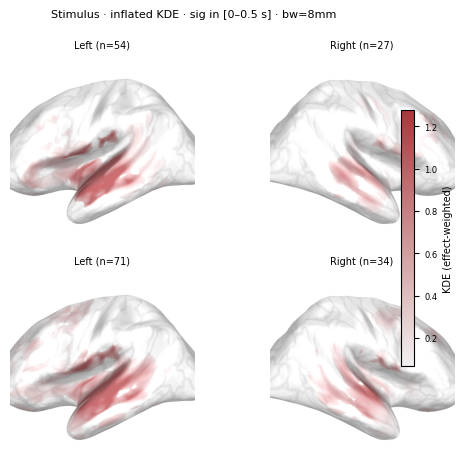

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2681640780.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


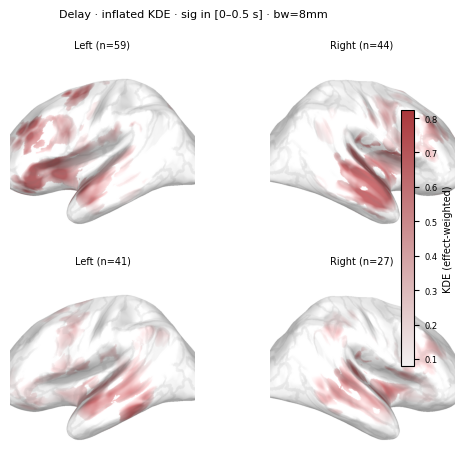

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2681640780.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


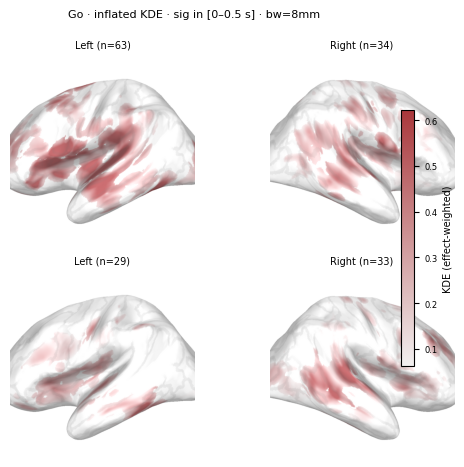

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2681640780.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


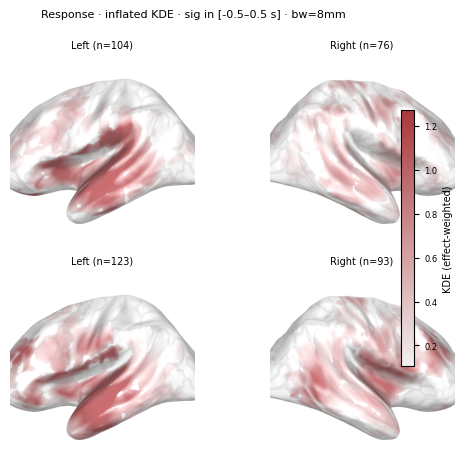

In [29]:
# Gaussian KDE params (vizpub/fig3_rt_legacy); coords = x_t,y_t,z_t with no offset
KDE_BANDWIDTH = 8.0  # mm
KDE_MAX_DISTANCE = 12.0  # mm
KDE_DENSITY_OPACITY = 0.75
KDE_N_COLORS = 1000


def _kde_colormap(base_rgb, n_colors=KDE_N_COLORS, opacity=KDE_DENSITY_OPACITY):
    """White (no data) → base color with alpha in the LUT itself."""
    colors_list = [[1.0, 1.0, 1.0, 1.0]]
    base = np.asarray(mcolors.to_rgb(base_rgb), dtype=float)
    for i in range(1, n_colors):
        intensity = i / (n_colors - 1)
        color = (1.0 - intensity) * np.array([1.0, 1.0, 1.0]) + intensity * base
        colors_list.append(list(color) + [opacity])
    return mcolors.ListedColormap(colors_list)


def _hemi_density(spatial_df, hemi):
    """Effect-weighted Gaussian density on pial vertices for one hemisphere."""
    pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
    hemi_code = "L" if hemi == "lh" else "R"
    sub = spatial_df[
        (spatial_df["hemi"] == hemi_code) & (~spatial_df[COORD_COLS].isna().any(axis=1))
    ]
    if sub.empty:
        return np.zeros(len(pial)), np.zeros(len(pial), dtype=bool), 0
    dens, mask = compute_density_unified(
        pial,
        sub[COORD_COLS].values,
        sub["effect"].values,
        bandwidth=KDE_BANDWIDTH,
        max_distance=KDE_MAX_DISTANCE,
    )
    return dens, mask, len(sub)


def _render_inflated_kde_panel(density, dens_mask, vmin, vmax, hemi, cmap):
    """Map pial density onto inflated Brain and return RGB screenshot."""
    setup_brain_offscreen()
    brain = make_inflated_brain(hemi)
    n_vertices = len(lh_infl_coords if hemi == "lh" else rh_infl_coords)
    data_to_plot = np.zeros(n_vertices)
    has_data = dens_mask & (density > 0)
    if has_data.any():
        norm = np.clip(
            (density[has_data] - vmin) / (vmax - vmin + 1e-12), 0.0, 1.0
        )
        data_to_plot[has_data] = 1.0 + norm * (KDE_N_COLORS - 2)

    brain.add_data(
        data_to_plot,
        hemi=hemi,
        colormap=cmap,
        alpha=1.0,
        colorbar=False,
        fmin=0,
        fmax=KDE_N_COLORS - 1,
    )
    try:
        brain.add_annotation("aparc.a2009s", borders=True, color="gray", alpha=0.35)
        for actor in brain._renderer.plotter.actors.values():
            prop = actor.GetProperty()
            if prop.GetRepresentation() == 1:  # wireframe = borders
                prop.SetLineWidth(0.1)
    except Exception:
        pass

    brain.show_view(view="lateral", distance=400)
    img = _brain_screenshot(brain)
    brain.close()
    return img


def plot_phase_kde_decision_vs_repeat(phase, base_color=None):
    """Inflated KDE: Decision (top) vs Repeat (bottom), L/R columns."""
    if base_color is None:
        base_color = red  # project red #A9373B
    tmin, tmax = TIME_WINDOWS[phase]
    frames = {
        desc: spatial_sig_in_window(phase, desc, tmin, tmax) for desc in DESCRIPTIONS
    }
    n_total = sum(len(v) for v in frames.values())
    if n_total == 0:
        print(f"{phase} ({tmin:g}–{tmax:g} s): no significant electrodes")
        return None

    # Precompute densities; shared scale within phase
    dens_cache = {}
    all_valid = []
    for desc, sp in frames.items():
        for hemi in ("lh", "rh"):
            dens, mask, n_e = _hemi_density(sp, hemi)
            dens_cache[(desc, hemi)] = (dens, mask, n_e)
            valid = dens[mask & (dens > 0)]
            if len(valid):
                all_valid.append(valid)

    if not all_valid:
        print(f"{phase}: electrodes present but density empty (check coords)")
        return None

    all_valid = np.concatenate(all_valid)
    vmin = float(np.percentile(all_valid, 2))
    vmax = float(np.percentile(all_valid, 96))
    if vmax <= vmin:
        vmax = vmin + 1e-6

    cmap = _kde_colormap(base_color)
    fig, axes = plt.subplots(2, 2, figsize=(14 * cm, 12 * cm))

    for row, desc in enumerate(DESCRIPTIONS):
        for col, hemi in enumerate(("lh", "rh")):
            dens, mask, n_e = dens_cache[(desc, hemi)]
            img = _render_inflated_kde_panel(dens, mask, vmin, vmax, hemi, cmap)
            ax = axes[row, col]
            ax.imshow(img)
            ax.axis("off")
            hemi_lab = "Left" if hemi == "lh" else "Right"
            n_ch = len(frames[desc])
            if col == 0:
                ax.set_ylabel(f"{desc}\n(n={n_ch})", fontsize=fontsize)
            ax.set_title(f"{hemi_lab} (n={n_e})", fontsize=fontsize)

    sm = plt.cm.ScalarMappable(
        cmap=sns.light_palette(base_color, as_cmap=True),
        norm=mcolors.Normalize(vmin=vmin, vmax=vmax),
    )
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
    cbar.set_label("KDE (effect-weighted)", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize - 1)

    win_lab = f"{tmin:g}–{tmax:g} s"
    plt.suptitle(
        f"{phase} · inflated KDE · sig in [{win_lab}] · bw={KDE_BANDWIDTH:g}mm",
        fontsize=fontsize + 1,
    )
    plt.tight_layout()
    return fig


print(
    f"KDE: bandwidth={KDE_BANDWIDTH}mm, max_distance={KDE_MAX_DISTANCE}mm; "
    "coords=x_t,y_t,z_t (no offset); surface=inflated"
)

for _phase in PHASES:
    _fig = plot_phase_kde_decision_vs_repeat(_phase)
    if _fig is not None:
        display(_fig)
        plt.close(_fig)


### Supplementary: electrode spheres (pial) + insula zoom

Same time-window selection as above, but discrete electrode spheres on **pial** (legacy scatter view). Useful for checking individual sites; main inference should use the inflated KDE maps.


Supplementary pial scatter (optional — skip if only need KDE):


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/1339979486.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


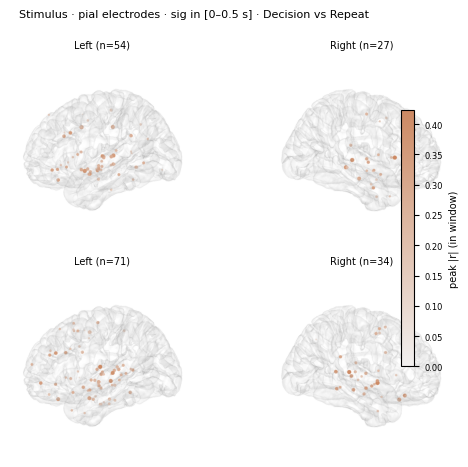

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/1339979486.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


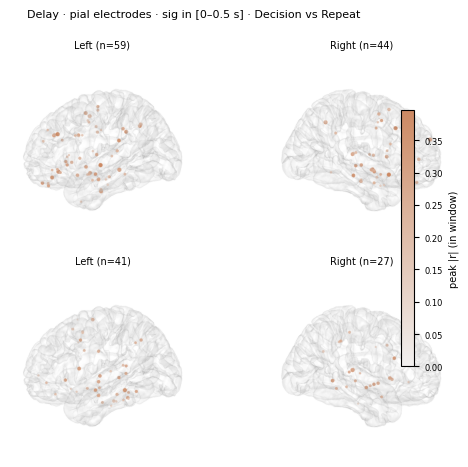

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/1339979486.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


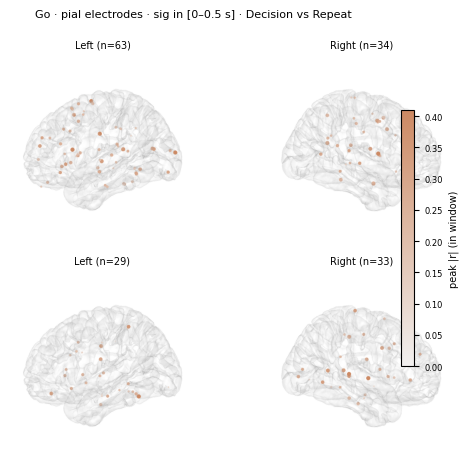

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/1339979486.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


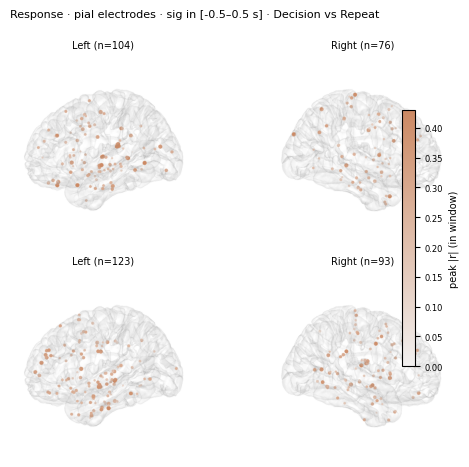

Insula zoom: 6 AIC/PIC channels (Decision / Delay 0–0.5 s)


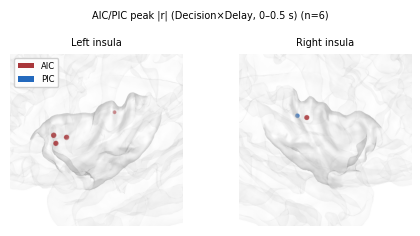

In [30]:
def _render_hemi_panel(spatial_df, hemi, vmin, vmax, cmap=oranges):
    """Pial electrode spheres for one hemisphere."""
    setup_brain_offscreen()
    brain = make_cortex_brain(hemi)
    sub = spatial_df[spatial_df["hemi"] == ("L" if hemi == "lh" else "R")]
    sub = sub[~sub[COORD_COLS].isna().any(axis=1)]
    if not sub.empty:
        tree = lh_tree if hemi == "lh" else rh_tree
        pial = lh_pial_coords if hemi == "lh" else rh_pial_coords
        add_electrodes_continuous(
            brain,
            sub[COORD_COLS].values,
            sub["effect"].values,
            tree,
            pial,
            cmap,
            vmin,
            vmax,
        )
    brain.show_view(view="lateral", distance=400)
    img = _brain_screenshot(brain)
    brain.close()
    return img


def plot_phase_decision_vs_repeat(phase, cmap=oranges):
    """Pial scatter: Decision (top) vs Repeat (bottom)."""
    tmin, tmax = TIME_WINDOWS[phase]
    frames = {
        desc: spatial_sig_in_window(phase, desc, tmin, tmax) for desc in DESCRIPTIONS
    }
    n_total = sum(len(v) for v in frames.values())
    if n_total == 0:
        print(f"{phase} ({tmin:g}–{tmax:g} s): no significant electrodes")
        return None

    all_effects = np.concatenate(
        [df["effect"].values for df in frames.values() if len(df)]
    )
    vmin = 0.0
    vmax = float(np.percentile(all_effects, 95)) if len(all_effects) else 0.3

    fig, axes = plt.subplots(2, 2, figsize=(14 * cm, 12 * cm))
    for row, desc in enumerate(DESCRIPTIONS):
        sp = frames[desc]
        for col, hemi in enumerate(("lh", "rh")):
            ax = axes[row, col]
            img = _render_hemi_panel(sp, hemi, vmin, vmax, cmap=cmap)
            ax.imshow(img)
            ax.axis("off")
            hemi_lab = "Left" if hemi == "lh" else "Right"
            n_hemi = int((sp["hemi"] == ("L" if hemi == "lh" else "R")).sum()) if len(sp) else 0
            if col == 0:
                ax.set_ylabel(f"{desc}\n(n={len(sp)})", fontsize=fontsize)
            ax.set_title(f"{hemi_lab} (n={n_hemi})", fontsize=fontsize)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.02)
    cbar.set_label("peak |r| (in window)", fontsize=fontsize)
    cbar.ax.tick_params(labelsize=fontsize - 1)

    win_lab = f"{tmin:g}–{tmax:g} s"
    plt.suptitle(
        f"{phase} · pial electrodes · sig in [{win_lab}] · Decision vs Repeat",
        fontsize=fontsize + 1,
    )
    plt.tight_layout()
    return fig


print("Supplementary pial scatter (optional — skip if only need KDE):")
for _phase in PHASES:
    _fig = plot_phase_decision_vs_repeat(_phase)
    if _fig is not None:
        display(_fig)
        plt.close(_fig)

# Insula zoom (Delay × DESCRIPTION)
_insula_phase = "Delay"
_tmin, _tmax = TIME_WINDOWS[_insula_phase]
spatial_sig = spatial_sig_in_window(_insula_phase, DESCRIPTION, _tmin, _tmax)
spatial_sig = spatial_sig[spatial_sig["roi"].isin(["AIC", "PIC"])].copy()

if spatial_sig.empty:
    print(
        f"No AIC/PIC cluster-sig in {_insula_phase} [{_tmin:g}–{_tmax:g} s] "
        f"for {DESCRIPTION}"
    )
else:
    print(
        f"Insula zoom: {len(spatial_sig)} AIC/PIC channels "
        f"({DESCRIPTION} / {_insula_phase} {_tmin:g}–{_tmax:g} s)"
    )
    fig = plot_spatial_encoding(
        spatial_sig,
        title=(
            f"AIC/PIC peak |r| ({DESCRIPTION}×{_insula_phase}, "
            f"{_tmin:g}–{_tmax:g} s)"
        ),
    )
    if fig is not None:
        display(fig)
        plt.close(fig)


## ROI time courses (fig2 style)

Group mean `|r|` over cluster-significant channel×time points. One row per task (**Decision**, **Repeat**); columns = phases.


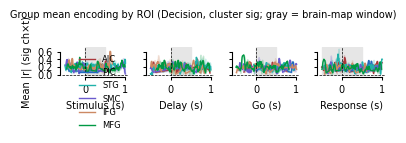

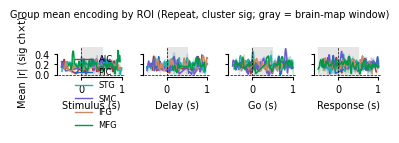

In [31]:
for _desc in DESCRIPTIONS:
    _long = long_all[long_all["description"] == _desc]
    if has_cluster_sig:
        _ts = build_roi_timeseries(_long[_long["significant"] == True])
    else:
        _ts = build_roi_timeseries(_long)

    fig, axes = plt.subplots(
        1,
        len(PHASES),
        figsize=(2.5 * len(PHASES) * cm, 3 * cm),
        sharey=True,
    )
    if len(PHASES) == 1:
        axes = [axes]

    for ax, phase in zip(axes, PHASES):
        ts = _ts[_ts["phase"] == phase] if "phase" in _ts.columns else _ts
        group_mean = (
            ts.groupby(["time", "roi_group"])["value"]
            .agg(
                mean="mean",
                sem=lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0,
            )
            .reset_index()
        )
        tmin, tmax = TIME_WINDOWS[phase]
        ax.axvspan(tmin, tmax, color="0.9", zorder=0)
        for roi in MAJOR_ROIS:
            sub = group_mean[group_mean["roi_group"] == roi]
            if sub.empty:
                continue
            color = ROI_COLORS[roi]
            ax.plot(sub["time"], sub["mean"], color=color, lw=1, label=roi)
            ax.fill_between(
                sub["time"],
                sub["mean"] - sub["sem"],
                sub["mean"] + sub["sem"],
                color=color,
                alpha=0.2,
            )
        ax.axvline(0, color="k", linestyle="--", linewidth=0.5)
        ax.axhline(0, color="k", linestyle="--", linewidth=0.5)
        ax.set_xlabel(f"{phase} (s)", fontsize=fontsize)
        ax.tick_params(labelsize=fontsize, width=0.75, length=2)
        sns.despine(ax=ax, offset=1, trim=True)
        if ax is axes[0]:
            ax.set_ylabel("Mean |r| (sig ch×t)", fontsize=fontsize)
            ax.legend(title="", fontsize=fontsize - 1, frameon=False, loc="upper right")

    plt.suptitle(
        f"Group mean encoding by ROI ({_desc}, cluster sig; gray = brain-map window)",
        fontsize=fontsize,
    )
    plt.tight_layout()
    plt.show()


## Channel heatmaps (major ROIs, fig2 style)

Cluster-significant `ch×t` only. Shown separately for **Decision** and **Repeat**. Columns = Stimulus / Delay / Go / Response. Gray band in ROI curves marks the brain-map selection window; heatmaps still show the full epoch for context.


=== Heatmaps: Decision ===


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


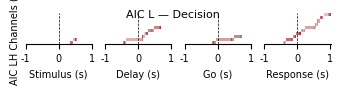

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


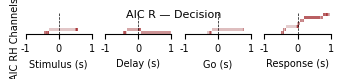

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


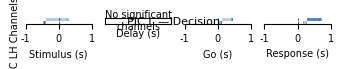

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


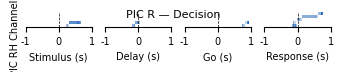

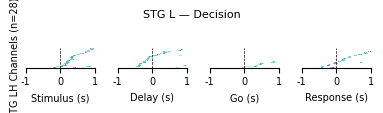

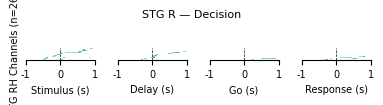

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


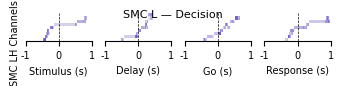

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


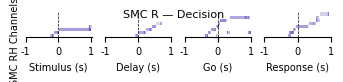

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


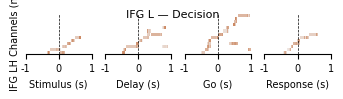

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


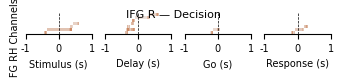

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


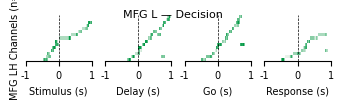

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


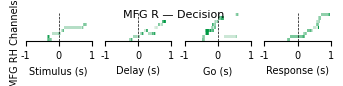

=== Heatmaps: Repeat ===


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


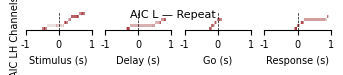

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


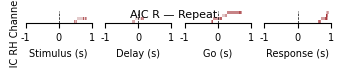

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


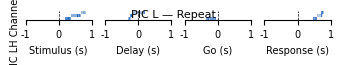

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


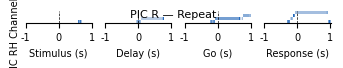

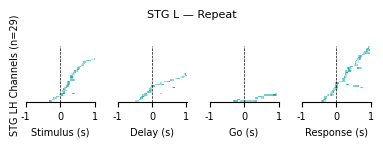

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


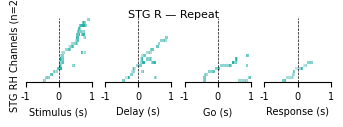

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


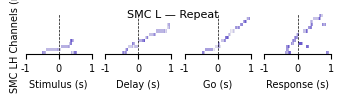

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


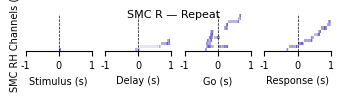

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


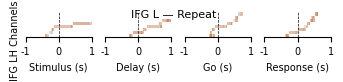

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


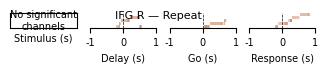

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


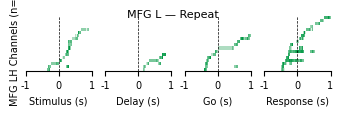

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_3490377/2686337002.py:113: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


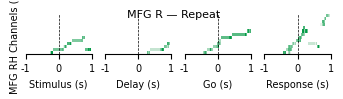

In [32]:
def plot_roi_encoding_heatmap(roi, hemi="L", cmap=None, vmax=None, description=None):
    """Channel × time heatmaps across phases (fig2 style)."""
    if cmap is None:
        cmap = ROI_CMAPS.get(roi, oranges)
    if description is None:
        description = DESCRIPTION
    if not has_cluster_sig:
        print(f"No cluster significance in H5; skipping {roi} heatmap")
        return

    subset = long_all[
        (long_all["description"] == description)
        & (long_all["significant"] == True)
        & (long_all["roi_group"] == roi)
        & (~long_all["mix"])
        & (long_all["hemi"] == hemi)
    ].copy()

    if subset.empty:
        print(f"No significant {roi} {hemi}H for {description}")
        return

    subset["ch_id"] = subset["subject"] + ":" + subset["channel"]

    phase_channel_map = {}
    max_channels = 0
    for phase in PHASES:
        phase_data = subset[subset["phase"] == phase]
        if phase_data.empty:
            phase_channel_map[phase] = []
            continue
        first_sig = phase_data.groupby("ch_id")["time"].min().sort_values()
        sorted_channels = first_sig.index.tolist()
        phase_channel_map[phase] = sorted_channels
        max_channels = max(max_channels, len(sorted_channels))

    if max_channels == 0:
        print(f"No significant {roi} {hemi}H for {description}")
        return

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(PHASES),
        figsize=(2.5 * len(PHASES) * cm, float(0.1 * max(max_channels, 1) * cm)),
        sharey=False,
    )
    if len(PHASES) == 1:
        axes = [axes]

    # Shared vmax across phases for this ROI/hemi
    if vmax is None:
        vals = subset["abs_r"].to_numpy()
        vmax = float(np.nanpercentile(vals, 95)) if vals.size else 0.4

    for ax, phase in zip(axes, PHASES):
        sorted_channels = phase_channel_map[phase]
        phase_data = subset[subset["phase"] == phase]

        if not sorted_channels:
            ax.text(
                0.5,
                0.5,
                "No significant\nchannels",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=fontsize,
            )
            ax.set_xlabel(f"{phase} (s)", fontsize=fontsize)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylim(0, max_channels)
            continue

        pivot = phase_data.pivot_table(
            index="ch_id", columns="time", values="abs_r", aggfunc="mean"
        )
        pivot = pivot.reindex(sorted_channels)

        times = pivot.columns.astype(float).values
        step = np.diff(times).mean() if len(times) > 1 else 0.01
        time_edges = np.concatenate(
            ([times[0] - step / 2], times[:-1] + step / 2, [times[-1] + step / 2])
        )
        ch_edges = np.arange(len(sorted_channels) + 1)
        T, C = np.meshgrid(time_edges, ch_edges)

        ax.pcolormesh(
            T,
            C,
            pivot.values,
            cmap=cmap,
            vmin=0,
            vmax=vmax,
            shading="auto",
            rasterized=True,
        )
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines["left"].set_visible(False)
        ax.set_xticks([-1, 0, 1])
        ax.set_xticklabels(["-1", "0", "1"], fontsize=fontsize)
        ax.set_yticks([])
        ax.set_xlabel(f"{phase} (s)", fontsize=fontsize)
        ax.axvline(0, color="k", linestyle="--", linewidth=0.5)
        ax.set_ylim(0, max_channels)
        if ax is axes[0]:
            ax.set_ylabel(
                f"{roi} {hemi}H Channels (n={len(sorted_channels)})",
                fontsize=fontsize,
            )

    plt.suptitle(f"{roi} {hemi} — {description}", fontsize=fontsize + 1)
    plt.tight_layout()
    plt.show()


for _desc in DESCRIPTIONS:
    print(f"=== Heatmaps: {_desc} ===")
    for _roi in MAJOR_ROIS:
        for _hemi in ("L", "R"):
            plot_roi_encoding_heatmap(
                _roi, hemi=_hemi, cmap=ROI_CMAPS[_roi], description=_desc
            )


## Optional: per-subject explorer

Exploratory only — not a main analysis result. Browse AIC/PIC electrodes for one subject × task × phase (full-epoch cluster sig, not time-window filtered).


In [33]:
try:
    import ipywidgets as widgets
    from IPython.display import clear_output

    print("Optional explorer — skip if you only need the group maps above.")

    desc_dd = widgets.Dropdown(
        options=DESCRIPTIONS,
        value=DESCRIPTION,
        description="Task",
    )
    phase_dd = widgets.Dropdown(
        options=PHASES,
        value="Delay",
        description="Phase",
    )
    out = widgets.Output()

    def _sig_subjects(description, phase):
        sp = spatial_sig_in_window(phase, description)
        sp = sp[sp["roi"].isin(["AIC", "PIC"])]
        return sorted(sp["subject"].unique()) if len(sp) else []

    subj_dd = widgets.Dropdown(
        options=_sig_subjects(DESCRIPTION, "Delay")
        or sorted(channels_all["subject"].unique()),
        description="Subject",
    )

    def _refresh_subjects(*_):
        opts = _sig_subjects(desc_dd.value, phase_dd.value)
        subj_dd.options = opts if opts else sorted(channels_all["subject"].unique())

    def _plot_subject(subject, description, phase):
        sp = spatial_sig_in_window(phase, description)
        sub = sp[
            (sp["subject"] == subject) & sp["roi"].isin(["AIC", "PIC"])
        ]
        if sub.empty:
            tmin, tmax = TIME_WINDOWS[phase]
            print(
                f"sub-{subject}: no AIC/PIC in window "
                f"[{tmin:g}–{tmax:g} s] for {description}/{phase}"
            )
            return
        tmin, tmax = TIME_WINDOWS[phase]
        fig = plot_spatial_encoding(
            sub,
            title=(
                f"sub-{subject} peak |r| ({description}×{phase}, "
                f"{tmin:g}–{tmax:g} s)"
            ),
        )
        if fig is not None:
            display(fig)
            plt.close(fig)

    def _redraw(*_):
        with out:
            clear_output(wait=True)
            _plot_subject(subj_dd.value, desc_dd.value, phase_dd.value)

    desc_dd.observe(_refresh_subjects, names="value")
    phase_dd.observe(_refresh_subjects, names="value")
    desc_dd.observe(_redraw, names="value")
    phase_dd.observe(_redraw, names="value")
    subj_dd.observe(_redraw, names="value")

    display(widgets.HBox([desc_dd, phase_dd, subj_dd]), out)
    _refresh_subjects()
    _redraw()
except ImportError:
    print("ipywidgets not installed; skip per-subject widget")


Optional explorer — skip if you only need the group maps above.


Output()